# 🌿 Crop Disease Detection — M3: Model Training Pipeline

## Group 8
### ResNet-50 | Small-Scale Pipeline Verification


In [5]:
# Install all required libraries
!pip install -q torch torchvision scikit-learn matplotlib seaborn

In [6]:
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Setting seeds ensures results are reproducible — same random numbers every run
random.seed(42)
torch.manual_seed(42)

# Use GPU if available, otherwise fall back to CPU
# GPU significantly speeds up training for image models
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [7]:
# Mount Google Drive to access the processed dataset saved in M2
from google.colab import drive
drive.mount('/content/drive')

# Paths to the train/val/test folders created by the M2 preprocessing pipeline
# DRIVE_PROCESSED = '/content/drive/MyDrive/CropDisease/processed'
DRIVE_PROCESSED = '/content/drive/MyDrive/DSAI Lab/DASI Lab Project/dataset/processed'
TRAIN_DIR = os.path.join(DRIVE_PROCESSED, 'train')
VAL_DIR   = os.path.join(DRIVE_PROCESSED, 'val')
TEST_DIR  = os.path.join(DRIVE_PROCESSED, 'test')

NUM_CLASSES   = 17      # Total disease/healthy classes across all 5 crops
BATCH_SIZE    = 32      # Number of images processed together in one forward pass
NUM_EPOCHS    = 10      # Number of times the model sees the entire training subset
LEARNING_RATE = 1e-4    # Step size for weight updates — small value for fine-tuning
SUBSET_PCT    = 0.2     # Use 20% of each class — proportionally fair across all classes

# These are the exact mean and std values used when ResNet-50 was trained on ImageNet
# We must use the same values so pretrained weights work correctly on our images
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Training transforms — applied to every image before it enters the model during training
train_transform = transforms.Compose([
    transforms.Resize(256),            # Resize shorter side to 256px first
    transforms.CenterCrop(224),        # Crop center 224x224 — focuses on leaf, reduces background noise
    transforms.RandomHorizontalFlip(), # Randomly flip image — makes model robust to leaf orientation
    transforms.ToTensor(),             # Convert PIL image (H,W,C) to PyTorch tensor (C,H,W), scale 0-255 to 0-1
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # Normalize to ImageNet distribution
])

# Validation/Test transforms — NO augmentation, only the essential resize+normalize
# We never augment val/test because we want a fair, consistent evaluation
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ImageFolder reads the folder structure created in M2:
# processed/train/ClassName/*.jpg  →  automatically assigns labels from folder names
full_train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
full_val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_transform)
full_test_ds  = datasets.ImageFolder(TEST_DIR,  transform=val_transform)

# CLASS_NAMES is a list like ['Corn__Common_Rust', 'Corn__Healthy', ...]
# automatically detected from folder names by ImageFolder
CLASS_NAMES = full_train_ds.classes
print(f'Train : {len(full_train_ds)} | Val : {len(full_val_ds)} | Test : {len(full_test_ds)}')

Train : 13170 | Val : 1277 | Test : 1277


In [9]:
# Build a proportional subset — takes 20% of each class
# This is fairer than a fixed number (e.g. 50/class) because some classes
# have 100 images and some have 800+ — a fixed number would over-represent small classes
def make_subset(dataset, percentage=0.2):
    # Group all image indices by their class label
    class_indices = {i: [] for i in range(len(dataset.classes))}
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    selected = []
    for label, indices in class_indices.items():
        n = max(1, int(len(indices) * percentage))  # at least 1 image per class
        selected.extend(random.sample(indices, n))  # randomly pick n images
    return Subset(dataset, selected)

subset_train_ds = make_subset(full_train_ds, SUBSET_PCT)
subset_val_ds   = make_subset(full_val_ds,   SUBSET_PCT)
subset_test_ds  = make_subset(full_test_ds,  SUBSET_PCT)

# DataLoader handles batching, shuffling, and parallel loading
# shuffle=True for train so the model doesn't see classes in the same order every epoch
# shuffle=False for val/test so evaluation is consistent and reproducible
train_loader = DataLoader(subset_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(subset_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(subset_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Subset train : {len(subset_train_ds)} images (20% per class)')
print(f'Subset val   : {len(subset_val_ds)} images (20% per class)')
print(f'Subset test  : {len(subset_test_ds)} images (20% per class)')

Subset train : 2628 images (20% per class)
Subset val   : 251 images (20% per class)
Subset test  : 251 images (20% per class)


In [10]:
# Load ResNet-50 with pretrained ImageNet weights
# Pretrained weights mean the model already knows how to detect edges, textures,
# and shapes — we just need to fine-tune it for crop disease specifically
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all layers except layer4 and fc (final layers)
# Freezing = weights won't update during training
# We freeze early layers because they already learned general features (edges, colors)
# We only train the later layers that learn task-specific features
for name, param in model.named_parameters():
    if not any(l in name for l in ['layer4', 'fc']):
        param.requires_grad = False

# Replace the final fully connected layer
# Original ResNet-50 fc: 2048 → 1000 (ImageNet classes)
# Our new fc: 2048 → 17 (our crop disease classes)
# Dropout(0.3) randomly zeros 30% of neurons during training to prevent overfitting
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)
model = model.to(DEVICE)  # Move model to GPU/CPU

# CrossEntropyLoss — standard loss for multi-class classification
# Internally applies softmax and measures how wrong the predictions are
criterion = nn.CrossEntropyLoss()

# Adam optimizer — updates only the trainable parameters (layer4 + fc)
# weight_decay adds L2 regularization to reduce overfitting
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=1e-4
)

# Scheduler reduces learning rate by half if val loss doesn't improve for 2 epochs
# This helps the model converge more precisely in later training stages
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


Trainable parameters: 14,999,569


In [11]:
# Dictionary to store loss and accuracy after each epoch for plotting
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):

    # ── Training Phase ────────────────────────────────────────────────────────
    model.train()  # Sets model to training mode — enables dropout and batch norm updates
    t_loss, t_correct, t_total = 0.0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)  # Move batch to GPU/CPU

        optimizer.zero_grad()        # Clear gradients from previous batch
        out  = model(imgs)           # Forward pass — model predicts class logits
        loss = criterion(out, labels) # Calculate how wrong the predictions are
        loss.backward()              # Backpropagation — compute gradients
        optimizer.step()             # Update weights using computed gradients

        # Accumulate loss and correct predictions for epoch-level metrics
        t_loss    += loss.item() * imgs.size(0)               # Multiply by batch size for weighted average
        t_correct += (out.argmax(1) == labels).sum().item()   # Count correct predictions
        t_total   += imgs.size(0)

    # ── Validation Phase ──────────────────────────────────────────────────────
    model.eval()  # Sets model to eval mode — disables dropout for consistent predictions
    v_loss, v_correct, v_total = 0.0, 0, 0

    with torch.no_grad():  # Disable gradient computation — saves memory, speeds up eval
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, labels)
            v_loss    += loss.item() * imgs.size(0)
            v_correct += (out.argmax(1) == labels).sum().item()
            v_total   += imgs.size(0)

    # Compute epoch-level averages
    tl = t_loss/t_total; ta = t_correct/t_total
    vl = v_loss/v_total; va = v_correct/v_total

    history['train_loss'].append(tl); history['train_acc'].append(ta)
    history['val_loss'].append(vl);   history['val_acc'].append(va)

    scheduler.step(vl)  # Pass val loss to scheduler — reduces LR if no improvement
    print(f'Epoch {epoch+1:2d} | Train Loss: {tl:.4f} Acc: {ta:.4f} | Val Loss: {vl:.4f} Acc: {va:.4f}')

print('\n✅ Training complete')

Epoch  1 | Train Loss: 0.8411 Acc: 0.7591 | Val Loss: 0.2121 Acc: 0.9203


Epoch  2 | Train Loss: 0.2033 Acc: 0.9391 | Val Loss: 0.2270 Acc: 0.9323


Epoch  3 | Train Loss: 0.1527 Acc: 0.9463 | Val Loss: 0.1879 Acc: 0.9163


Epoch  4 | Train Loss: 0.1161 Acc: 0.9631 | Val Loss: 0.1841 Acc: 0.9363


Epoch  5 | Train Loss: 0.1024 Acc: 0.9688 | Val Loss: 0.2253 Acc: 0.9243


Epoch  6 | Train Loss: 0.0590 Acc: 0.9825 | Val Loss: 0.1519 Acc: 0.9442


Epoch  7 | Train Loss: 0.0449 Acc: 0.9897 | Val Loss: 0.1757 Acc: 0.9283


Epoch  8 | Train Loss: 0.0574 Acc: 0.9825 | Val Loss: 0.1904 Acc: 0.9203


Epoch  9 | Train Loss: 0.0403 Acc: 0.9901 | Val Loss: 0.2267 Acc: 0.9203


Epoch 10 | Train Loss: 0.0389 Acc: 0.9890 | Val Loss: 0.1519 Acc: 0.9482

✅ Training complete


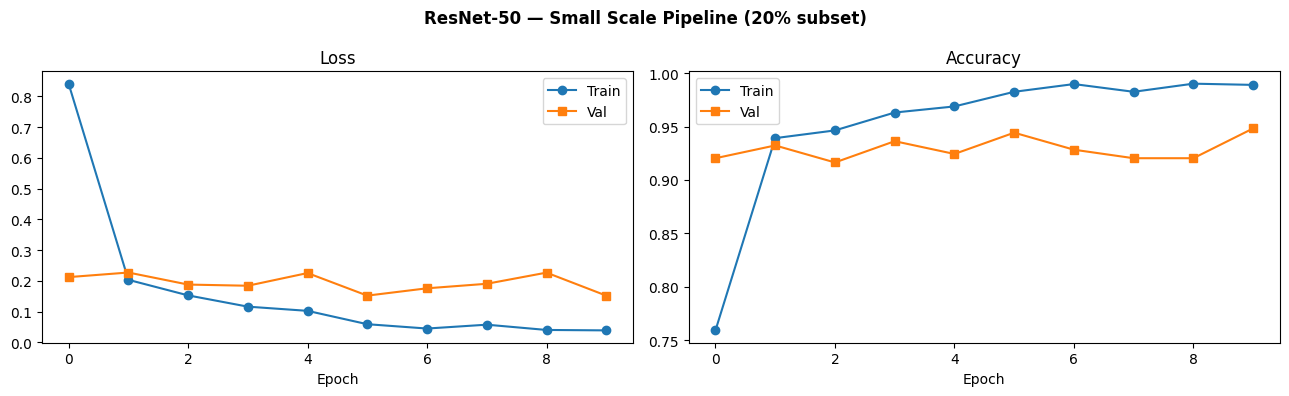

In [12]:
# Plot loss and accuracy curves to visualize training progress
# Ideally both train and val curves should decrease/increase together
# A large gap between them indicates overfitting
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'],   label='Val',   marker='s')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'],   label='Val',   marker='s')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.suptitle('ResNet-50 — Small Scale Pipeline (20% subset)', fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()

In [13]:
# Evaluate the trained model on the test subset
# Test set was never seen during training or validation — gives unbiased performance estimate
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        imgs  = imgs.to(DEVICE)
        preds = model(imgs).argmax(dim=1)  # Pick the class with the highest logit score
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f'Test Accuracy : {accuracy_score(all_labels, all_preds):.4f}')
print()
# Classification report shows per-class precision, recall, and F1-score
# Precision  = of all predicted as class X, how many were actually X
# Recall     = of all actual class X images, how many did the model find
# F1-score   = harmonic mean of precision and recall
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=3))

Testing: 100%|██████████| 8/8 [01:32<00:00, 11.58s/it]

Test Accuracy : 0.9442

                             precision    recall  f1-score   support

         Corn___Common_Rust      1.000     1.000     1.000        23
      Corn___Gray_Leaf_Spot      0.818     0.900     0.857        10
             Corn___Healthy      1.000     1.000     1.000        23
Corn___Northern_Leaf_Blight      0.944     0.895     0.919        19
      Potato___Early_Blight      1.000     1.000     1.000        20
           Potato___Healthy      1.000     1.000     1.000         3
       Potato___Late_Blight      1.000     1.000     1.000        20
          Rice___Brown_Spot      0.875     0.636     0.737        11
             Rice___Healthy      0.793     0.920     0.852        25
          Rice___Leaf_Blast      0.750     0.706     0.727        17
          Rice___Neck_Blast      1.000     1.000     1.000        16
 Sugarcane_Bacterial Blight      1.000     1.000     1.000         2
          Sugarcane_Healthy      1.000     1.000     1.000         2
         

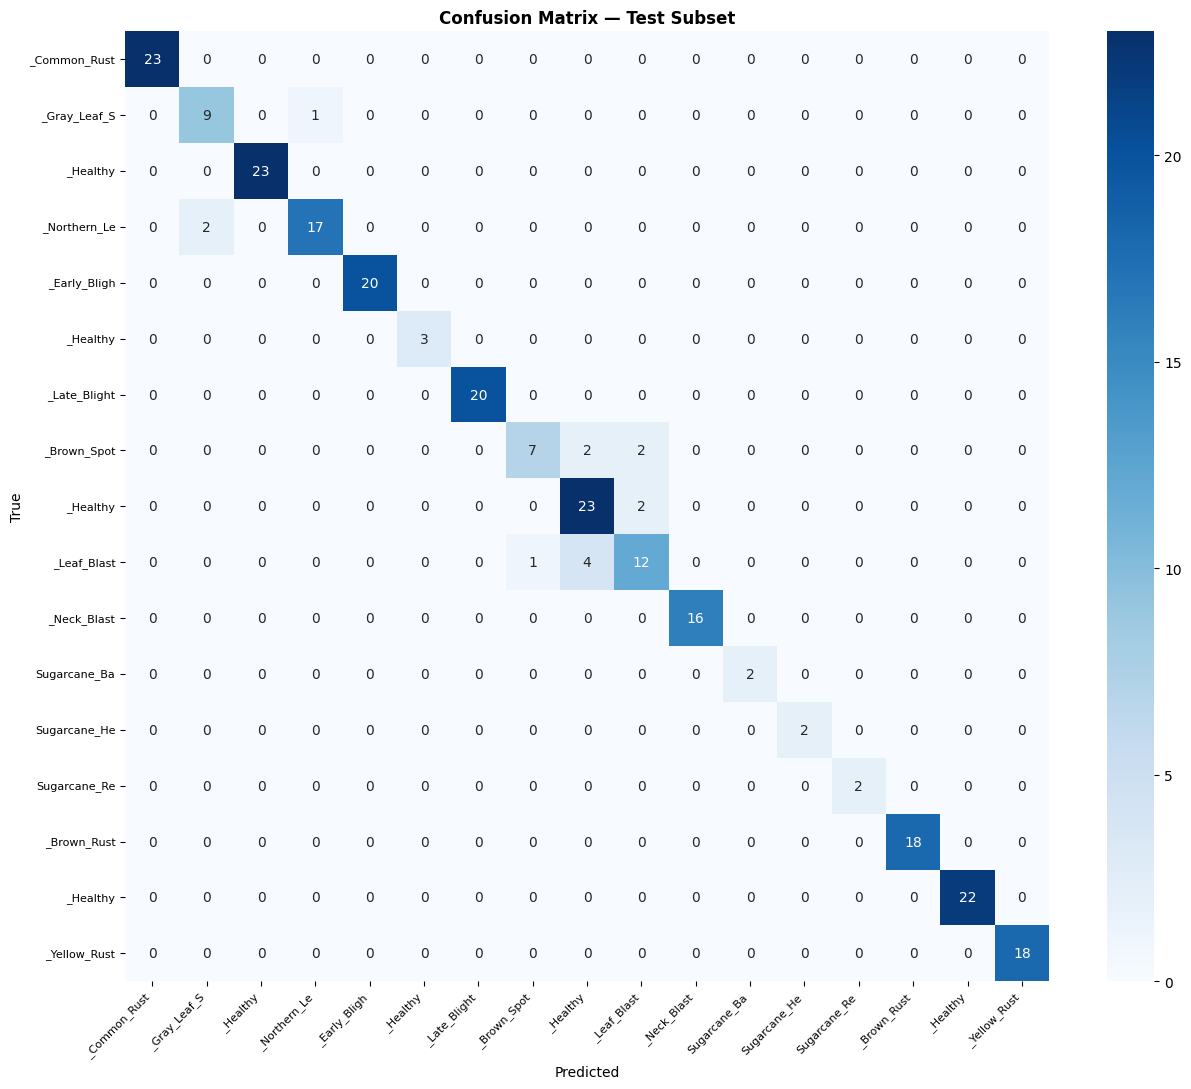

In [14]:
# Confusion matrix shows which classes get confused with each other
# Diagonal = correct predictions, Off-diagonal = misclassifications
# Useful for spotting if e.g. two similar diseases are being mixed up
cm = confusion_matrix(all_labels, all_preds)
short_names = [c.split('__')[-1][:12] for c in CLASS_NAMES]  # Shorten names to fit on plot

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Test Subset', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

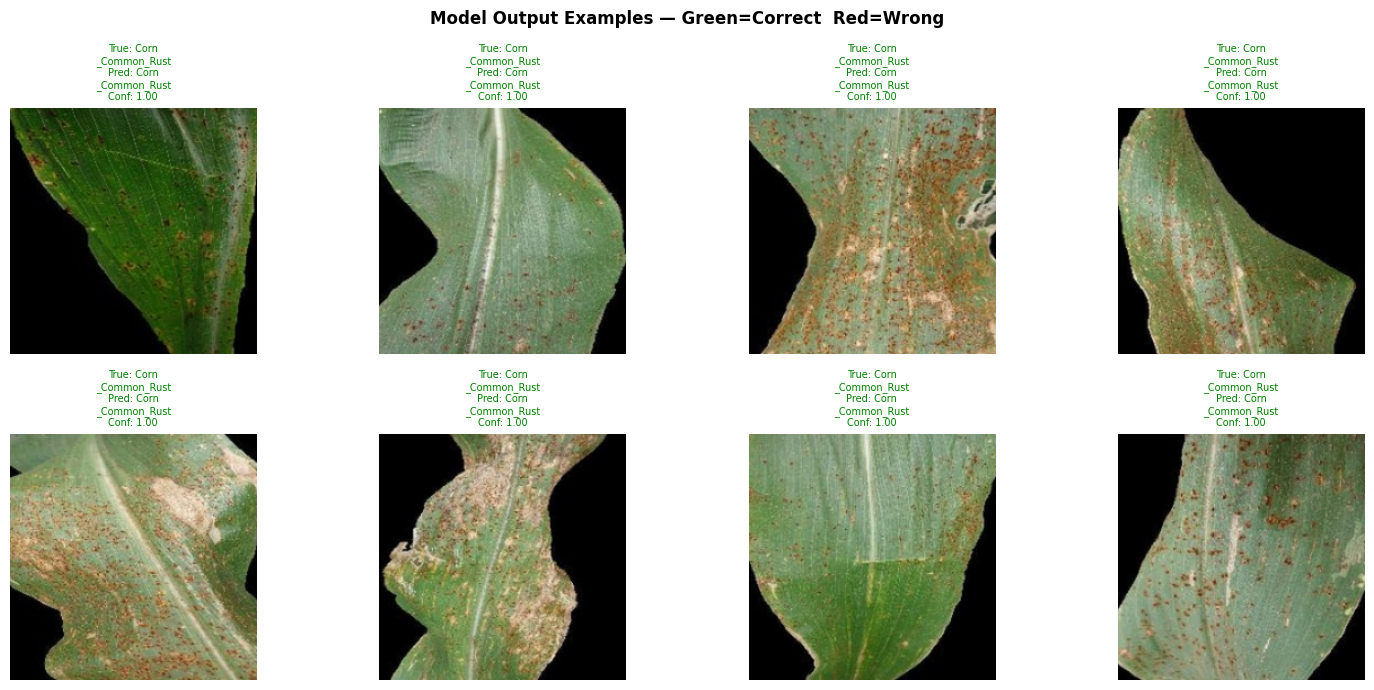

In [15]:
# Reverse the normalization applied during transforms so images look natural for display
# Without this step images would appear washed out / wrong colors
def denormalize(tensor):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
        t[c] = t[c] * s + m   # Reverse: pixel = (normalized * std) + mean
    return t.clamp(0, 1)       # Clamp to valid range [0, 1]

model.eval()
imgs, labels = next(iter(test_loader))  # Grab one batch from test set

with torch.no_grad():
    probs = torch.softmax(model(imgs.to(DEVICE)), dim=1).cpu()  # Convert logits to probabilities (sum to 1)
    preds = probs.argmax(dim=1)        # Predicted class index
    confs = probs.max(dim=1).values    # Confidence = probability of predicted class

# Display 8 test images with true label, predicted label, and confidence
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for i, ax in enumerate(axes.flatten()):
    img_disp  = denormalize(imgs[i]).permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C) for matplotlib
    true_name = CLASS_NAMES[labels[i].item()].replace('__', '\n')
    pred_name = CLASS_NAMES[preds[i].item()].replace('__', '\n')
    correct   = preds[i] == labels[i]
    color     = 'green' if correct else 'red'  # Green border = correct, Red = wrong
    ax.imshow(img_disp)
    ax.set_title(f'True: {true_name}\nPred: {pred_name}\nConf: {confs[i]:.2f}',
                 fontsize=7, color=color)
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2.5)
    ax.axis('off')

plt.suptitle('Model Output Examples — Green=Correct  Red=Wrong', fontweight='bold')
plt.tight_layout()
plt.savefig('output_examples.png', bbox_inches='tight')
plt.show()